# Numerical Solution of the Time-Independant Schrödinger Equation

The general time-independant Schrödinger equation is $\hat{H} \ket{\psi_n} = E_n \ket{\psi_n}$; if we take the case of a single particle with a time-independant potential function, this becomes $- \frac{\hbar ^ 2}{2 m} \frac{d ^ 2 \psi(x)}{d x ^ 2} + V (x) \psi (x) = E \psi (x)$.
In this notebook, I'm goig to solve the time-independant Schrödinger equation numerically for this one dimensional case by discretizing space and converting the equation into a matrix eigenvalue problem.

In [1]:
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt

## 1. Discretization of the TISE

In order to solve the equation numerically, I have to discretize the spatial domain by using a finite set of grid points for $x$ instead of a continuous coordinate. In a discretized space, $x_i = x_0 + (i - 1) \Delta x$, with $\Delta x$ being the tiny increment between each two consecutive points. The notation $\psi_i = \psi(x_i)$ will be used throughout the notebook.
Taylor expansions of $\psi_{i+1}$ and $\psi_{i-1}$ for very small $\Delta x$ will be as such:
$$\psi_{i+1} = \psi_i + \psi_i ' \Delta x + \frac{\psi_i ''}{2} \Delta x + \mathcal{O} ((\Delta x)^3)$$
$$\psi_{i-1} = \psi_i - \psi_i ' \Delta x + \frac{\psi_i ''}{2} \Delta x + \mathcal{O} ((\Delta x)^3)$$
Rearranging this and solving for $\psi_i ''$, we have:
$$\psi_i '' \approx \frac{\psi_{i+1} - 2 \psi_i + \psi_{i-1}}{(\Delta x)^2}$$
Substituting this into the TISE will yield:
$$- \frac{\hbar ^ 2}{2 m} \frac{d ^ 2 \psi(x)}{d x ^ 2} + V (x) \psi (x) = E \psi (x)$$
$$\rightarrow - \frac{\hbar^2}{2m}(\frac{\psi_i - 2 \psi_i + \psi_{i - 1}}{(\Delta x)^2}) + V_i \psi_i = E \psi_i$$
This equation is linear in all $\psi_i$, and it can be made into a matrix equation in order to be solved for its eigenvalues. I will now discretize the kinetic and the potential term seperately.

### 1.1 Discretization of the kinetic energy operator

The first term in the LHS of the discretized TISE above, is the kinetic term of the Hamiltonian operator. It can be represented in a tridiagonal matrix form. Collecting all the constants together, $a = \frac{\hbar^2}{2m(\Delta x)^2}$, it can be represented as:
$$ T = \begin{pmatrix}
2a & -a & 0 & 0 & \cdots & 0 \\
-a & 2a & -a & 0 & \cdots & 0 \\
0 & -a & 2a & -a & \cdots & 0 \\
0 & 0 & -a & 2a & \ddots & \vdots \\
\vdots & \vdots & \vdots & \ddots & \ddots & -a \\
0 & 0 & 0 & \cdots & -a & 2a
\end{pmatrix}$$


### 1.2 Discretization of the potential energy operator

Similarly, the potential term in the LHS of the TISE can also be represented in a matrix form, and it is even simpler than the kinetic term because it is only a diagonal matrix:
$$V = \begin{pmatrix}
V_0 & 0 & 0 & 0 & \cdots & 0 \\
0 & V_1 & 0 & 0 & \cdots & 0 \\
0 & 0 & V_2 & 0 & \cdots & 0 \\
0 & 0 & 0 & V_3 & \ddots & \vdots \\
\vdots & \vdots & \vdots & \ddots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & \cdots & V_n
\end{pmatrix}$$

### 1.3 Discretized Hamiltonian and the matrix equation

Now that both the energy terms are discretized, all that remains is to add them up and construct the descretized Hamiltonian matrix. It will be as such:
$$H = T + V$$
where $ T $ and $ V $ are the discretized matrices derived above. The TISE now reads:
$$ H\psi = E \psi$$
Which in matrix form is:
$$\begin{pmatrix}
2a + V_0 & -a & 0 & 0 & \cdots & 0 \\
-a & 2a + V_1 & -a & 0 & \cdots & 0 \\
0 & -a & 2a + V_2 & -a & \cdots & 0 \\
0 & 0 & -a & 2a + V_3 & \ddots & \vdots \\
\vdots & \vdots & \vdots & \ddots & \ddots & -a \\
0 & 0 & 0 & \cdots & -a & 2a + V_n
\end{pmatrix}
\begin{pmatrix}
\psi_0 \\
\psi_1 \\
\psi_2 \\
\psi_3 \\
\vdots \\
\vdots \\
\psi_n
\end{pmatrix} =
E
\begin{pmatrix}
\psi_0 \\
\psi_1 \\
\psi_2 \\
\psi_3 \\
\vdots \\
\vdots \\
\psi_n
\end{pmatrix}
$$

## 2. Numerical Solutions for the Quantum Harmonic Oscillator

I will now solve the matrix eigenvalue equation derived above for the 1D quantum harmonic oscillator, graph the results, and compare them to the analytical solutions. In order to do this, I will first make a discrete x grid, construct the kinetic and the potential matrices, solve the eigenvalue equation using SciPy, and finally graph them and compare them to the analytical results.

### 2.1 Discrete x grid

Just as discussed above, the spatial domain should be discretized by making a finite set of grid points for $x$.

In [2]:
x_max = 10
x_min = -10
N = 2001

x = np.linspace(x_min, x_max, N)
dx = x[1] - x[0]

In [3]:
x

array([-10.  ,  -9.99,  -9.98, ...,   9.98,   9.99,  10.  ], shape=(2001,))

In [4]:
dx

np.float64(0.009999999999999787)

This is a discrete x grid, running from $x = -10$ to $x = 10$, and with a step size of $\Delta x = 0.01$.

### 2.2 Kinetic energy matrix

I will then construct the kinetic energy matrix, the same one derived in the first section. This matrix is a general one and isn't limited to the case of a harmonic oscillator.

In [5]:
#defining the paramters and the constant a

hbar = 1
m = 1

a = hbar ** 2 / (2 * m * dx ** 2)

#constructing the tridiagonal T matrix itself
T = (
    2 * a * np.eye(N)
    - a * np.diag(np.ones(N-1), 1)
    - a * np.diag(np.ones(N-1), -1)
)

In [6]:
T

array([[10000., -5000.,     0., ...,     0.,     0.,     0.],
       [-5000., 10000., -5000., ...,     0.,     0.,     0.],
       [    0., -5000., 10000., ...,     0.,     0.,     0.],
       ...,
       [    0.,     0.,     0., ..., 10000., -5000.,     0.],
       [    0.,     0.,     0., ..., -5000., 10000., -5000.],
       [    0.,     0.,     0., ...,     0., -5000., 10000.]],
      shape=(2001, 2001))

The very same tridiagonal matrix derived in the first section.

### 2.3 Potential energy matrix

The potential energy for the quantum harmonic oscillator can be written as such:$$V(x) = \frac{1}{2} m \omega^2 x^2$$
I will first make a 1D array of $V_i$, plot it, and then construct the matrix.

In [7]:
#defining omega, and constructing the 1D potential array

omega = 1

V = 0.5 * m * omega ** 2 * x ** 2

Text(0.5, 1.0, 'Quantum Harmonic Oscillator Potential')

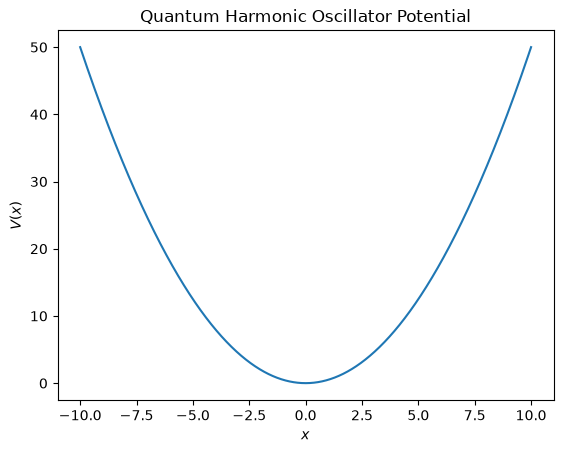

In [8]:
plt.plot(x, V)
plt.xlabel(r'$x$')
plt.ylabel(r'$V(x)$')
plt.title("Quantum Harmonic Oscillator Potential")

I will now construct the diagonal potential matrix.

In [9]:
#constructing the diagonal potential matrix from the array above

V = np.diag(V)

In [10]:
V

array([[50.     ,  0.     ,  0.     , ...,  0.     ,  0.     ,  0.     ],
       [ 0.     , 49.90005,  0.     , ...,  0.     ,  0.     ,  0.     ],
       [ 0.     ,  0.     , 49.8002 , ...,  0.     ,  0.     ,  0.     ],
       ...,
       [ 0.     ,  0.     ,  0.     , ..., 49.8002 ,  0.     ,  0.     ],
       [ 0.     ,  0.     ,  0.     , ...,  0.     , 49.90005,  0.     ],
       [ 0.     ,  0.     ,  0.     , ...,  0.     ,  0.     , 50.     ]],
      shape=(2001, 2001))

### 2.4 The Hamiltonian matrix and solving the eigenvalue problem

With the kinetic and the potential matrices, the Hamiltonian matrix can easily be constructed by adding them:

In [11]:
#constructing the Hamiltonian matrix

H = T + V

In [12]:
H

array([[10050.     , -5000.     ,     0.     , ...,     0.     ,
            0.     ,     0.     ],
       [-5000.     , 10049.90005, -5000.     , ...,     0.     ,
            0.     ,     0.     ],
       [    0.     , -5000.     , 10049.8002 , ...,     0.     ,
            0.     ,     0.     ],
       ...,
       [    0.     ,     0.     ,     0.     , ..., 10049.8002 ,
        -5000.     ,     0.     ],
       [    0.     ,     0.     ,     0.     , ..., -5000.     ,
        10049.90005, -5000.     ],
       [    0.     ,     0.     ,     0.     , ...,     0.     ,
        -5000.     , 10050.     ]], shape=(2001, 2001))

The TISE can be solved easily now.

In [13]:
#solving the eigenvalue problem using SciPy

E, psi = linalg.eigh(H)

In [14]:
E[:5]

array([0.49999687, 1.49998437, 2.49995937, 3.49992187, 4.49987187])

This is exactly what was expected! The first five eigenergies are half integers. The analytical formula for the energy levels of a quantum harmonic oscillator is:
$$E_n = \hbar \omega (n + \frac{1}{2})$$
Since I set $\hbar$ and $\omega$ to be $1$, this reduces to
$$E_n = n + \frac{1}{2}$$
The eigenergies I derived numerically are in agreement with this, as they are also half integers starting with 0.5 and going up.

### 2.5 Plotting the eigenenergies and the eigenvectors

I will now plot the eigenergies and the eigenvectors that I solved for numerically.

Text(0.5, 1.0, 'Harmonic Oscillator Energy Levels')

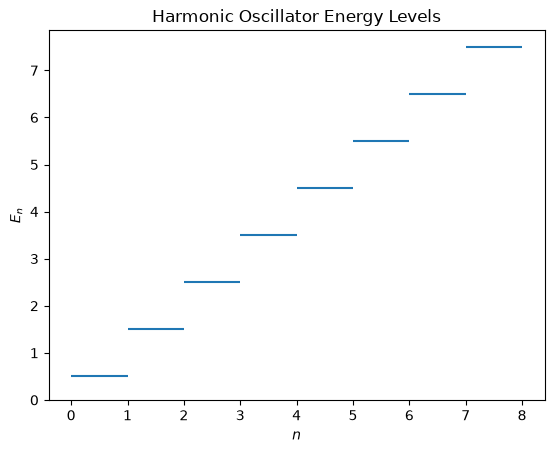

In [15]:
#plotting the eigenergies

N = 8
n = np.arange(N)

plt.hlines(E[:N], n, n + 1)

plt.xlabel(r'$n$')
plt.ylabel(r'$E_n$')
plt.ylim(bottom = 0)
plt.title("Harmonic Oscillator Energy Levels")

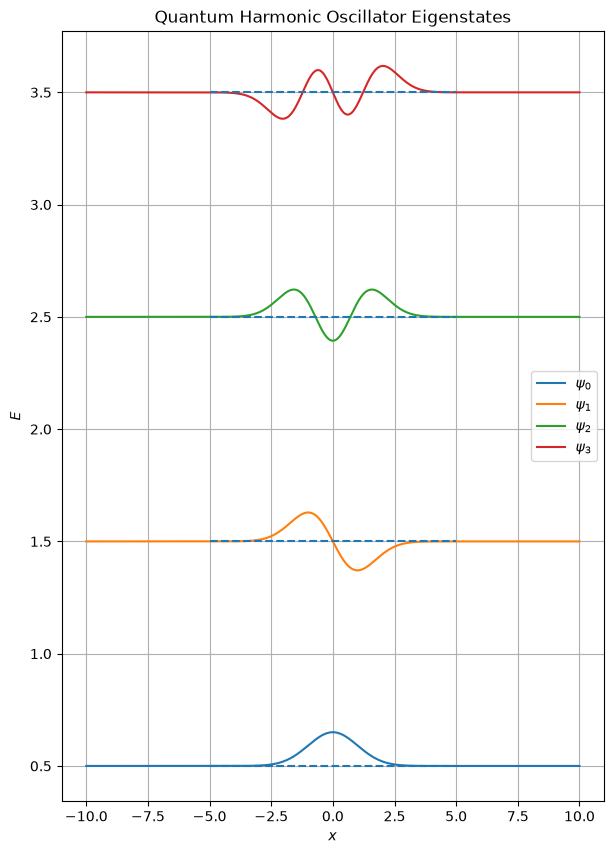

In [16]:
plt.figure(figsize=(7, 10))

scale = 2

for n in range(4):
    plt.plot(x, psi[:, n] * scale + E[n], label = fr"$\psi_{n}$")
    plt.hlines(E[n], -5, 5, linestyles = "--")



plt.xlabel(r"$x$")
plt.ylabel(r"$E$")
plt.title("Quantum Harmonic Oscillator Eigenstates")
plt.legend()
plt.grid()

## 3. Symmetric Quartic Double Well Potential

The quantum harmonic oscillator I solved for above, can be solved analytically, and they were useful to compare the analytical results and the numerical ones. I will now solve for a symmetric quartic double well potential, which has no analytical results. The general formula for this potential is:
$$ V(x) = a (x^2 - b^2)^2$$
It has two minima (wells) at points $x = \pm b$, and a finite barrier at $x = 0$.

### 3.1 The potential energy

As I mentioned earlier, the kinetic energy matrix is a general one and that same exact form applies to potentials other than the harmonic oscillator. Therefor, I only have to construct the potential energy matrix. As in the last section, I'm first going to make a 1D array of it, plot it, and then construct the actual diagonal potential energy matrix.

In [17]:
#choosing the parameters, and constructing the 1D potential array

a = 1
b = 2 #the minima will be at x = -2 and x = 2

V = a * (x ** 2 - b ** 2) ** 2

Text(0.5, 1.0, 'Symmetric Quartic Double Well')

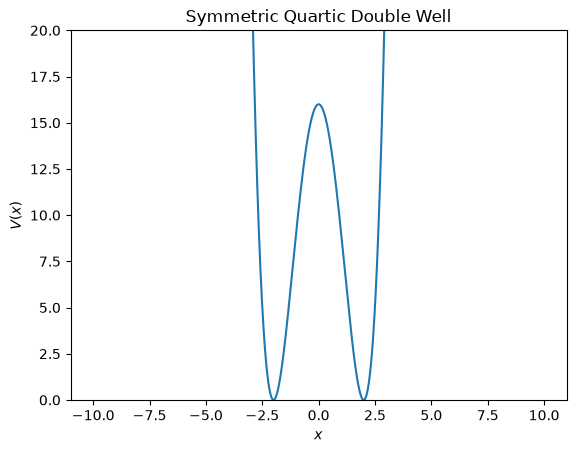

In [18]:
plt.plot(x, V)
plt.xlabel(r'$x$')
plt.ylabel(r'$V(x)$')
plt.ylim(0, 20 * a)
plt.title("Symmetric Quartic Double Well")

In [19]:
#constructing the diagonal potential energy matrix

V = np.diag(V)

In [20]:
V[:4, :4]

array([[9216.        ,    0.        ,    0.        ,    0.        ],
       [   0.        , 9177.65916001,    0.        ,    0.        ],
       [   0.        ,    0.        , 9139.43648016,    0.        ],
       [   0.        ,    0.        ,    0.        , 9101.33172081]])

### 3.2 The Hamiltonian matrix and solving the TISE

The Hamiltonian matrix can be constructed now by adding the kinetic energy matrix and the potential energy matrix, $H = T + V$.

In [21]:
#constructing the Hamiltonian matrix

H = T + V

In [22]:
H[:4, :4]

array([[19216.        , -5000.        ,     0.        ,     0.        ],
       [-5000.        , 19177.65916001, -5000.        ,     0.        ],
       [    0.        , -5000.        , 19139.43648016, -5000.        ],
       [    0.        ,     0.        , -5000.        , 19101.33172081]])

Now the TISE can be solved.

In [23]:
#solving the eigenvalue problem using SciPy

E, psi = linalg.eigh(H)

In [24]:
E[:6]

array([ 2.76231287,  2.76232877,  7.98850153,  7.99059906, 12.59537411,
       12.68897287])

### 3.3 Plotting the results

Text(0.5, 1.0, 'Symmetric Quartic Double Well Energy Levels')

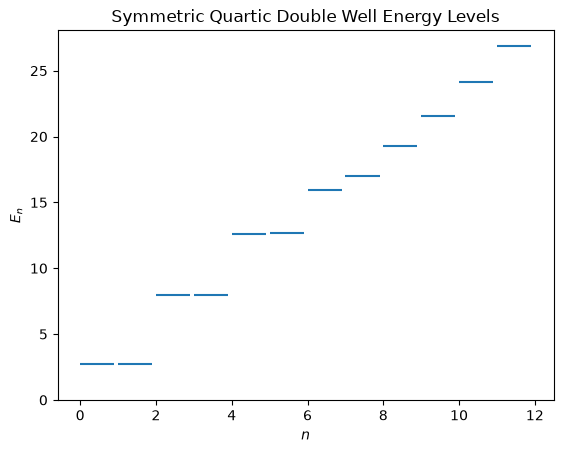

In [25]:
#plotting the eigenergies

N = 12
n = np.arange(N)

plt.hlines(E[:N], n, n + 0.9)

plt.xlabel(r'$n$')
plt.ylabel(r'$E_n$')
plt.ylim(bottom = 0)
plt.title("Symmetric Quartic Double Well Energy Levels")

This is interesting! For the energy levels, where the energy is lower than the potential barrier at $x = 0$, each consecutive pair is almost identical. This is due to the fact that the two wells, which are seperated by the barrier, act approximately like two independant systems, and if the barrier was an infinite one, this would indeed be the case and the energies would be degenerate. But since it is finite, tunneling occurs between the two wells which causes the slight split between the energies. But once the energy levels rise above $a b^4$, which is the potential of the barrier, this doesn't occur anymore.

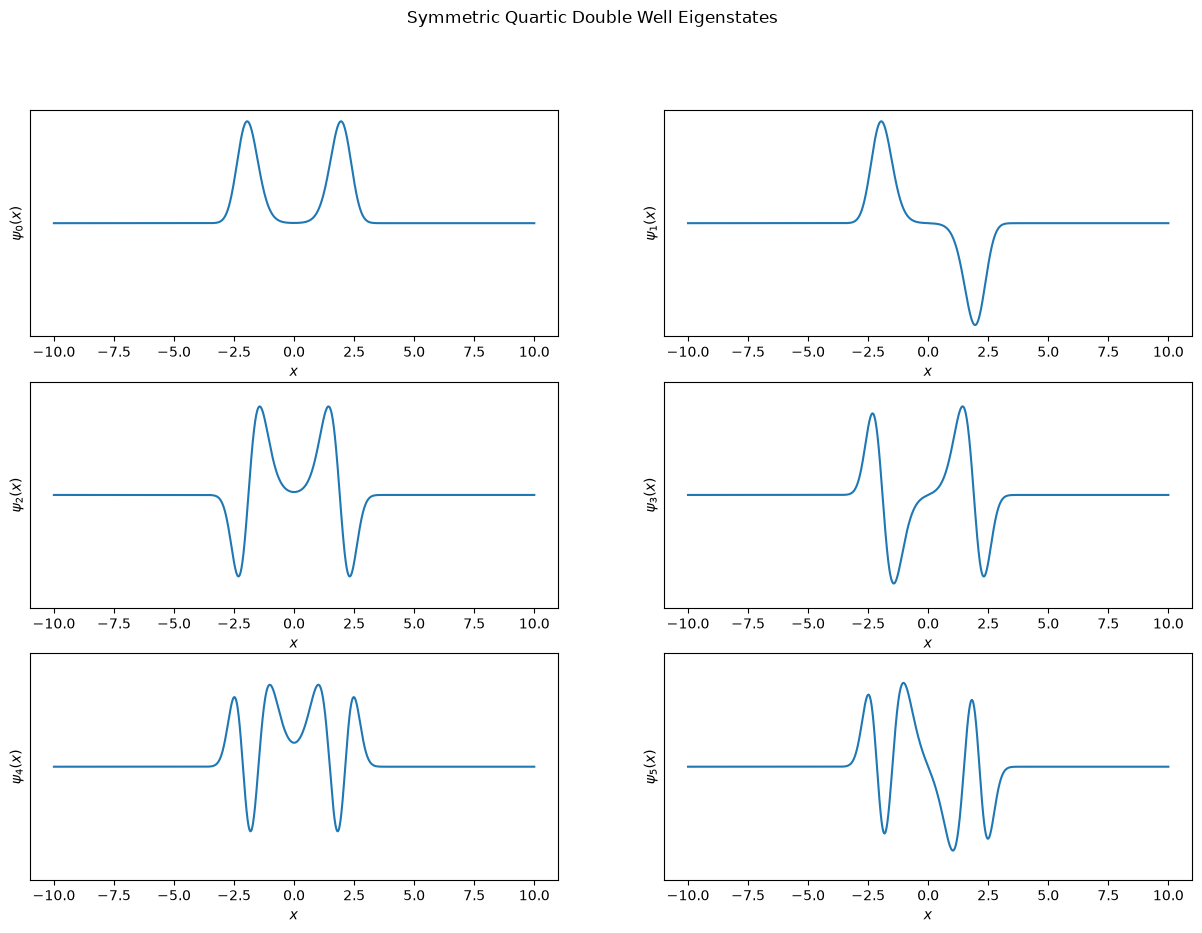

In [59]:
plt.figure(figsize=(15, 10))

N = 6

for i in range(N):
    plt.subplot(int(N/2), 2, i+1)
    plt.plot(x, psi[:, i])
    plt.xlabel(r'$x$')
    plt.ylabel(rf'$\psi_{i}(x)$')
    plt.ylim(-0.09, 0.09)
    plt.yticks([])

plt.suptitle("Symmetric Quartic Double Well Eigenstates")
plt.show()

Eigenstate pairs with nearyly degenerate energies, occur in alternating even/odd parity pairs.